In [1]:
import sys, os
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION']='.95'
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)
import jax
# Change the current working directory to the desired path
# os.chdir('/mnt/home/spandey/ceph/GODMAX/src/')
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
config.update("jax_enable_x64", True)
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import jax.numpy as jnp
import colossus 
from jax import vmap, grad
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
# Palatino
pl.rc('font', family='DejaVu Sans')
import matplotlib
%matplotlib inline
# deproj = sys.argv[1]
# probe = sys.argv[2]


/tmp/ipykernel_2692987/725694404.py:6: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


In [20]:
import dill
# df = dill.load(open(f'/projects/bdne/spandey3/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_6000_num_chains_12_thetaej_mubeta_zev_smoothing_mmym_response_power_add.pkl','rb'))
# df = dill.load(open(f'/projects/bdne/spandey3/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_6000_num_chains_12_narrowprior_thetaej_mubeta_zev_smoothing_mmym_response_response.pkl','rb'))
# df = dill.load(open(f'/projects/bdne/spandey3/GODMAX/results/chains/mcmc_probe_xip_xim_deproj_cib_1p7_dBeta_4000_6000_num_chains_12_narrowprior_thetaej_mubeta_zev_smoothing_mmym_response_power_add.pkl','rb'))
# df = dill.load(open(f'/projects/bdne/spandey3/GODMAX/results/chains_final_Nov/mcmc_probe_xip_xim_deproj_cib_1p7_dBeta_4000_6000_num_chains_4_narrowpriorfinal_thetaej_zev_mubeta_smoothing_mmym_power_add_power_add.pkl','rb'))
df = dill.load(open(f'/projects/bdne/spandey3/GODMAX/results/chains_final_Nov/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_6000_num_chains_4_narrowpriorfinal_thetaej_zev_mubeta_smoothing_mmym_response_response.pkl','rb'))
df.keys()




dict_keys(['A_IA', 'A_IA_base', 'Delta_z_bias_array', 'Delta_z_bias_array_decentered', 'Ob0', 'Ob0_base', 'Om0', 'Om0_base', 'alpha_nt', 'alpha_nt_base', 'diverging', 'eta_IA', 'eta_IA_base', 'h', 'h_base', 'mu_beta', 'mu_beta_base', 'mult_shear_bias_array', 'mult_shear_bias_array_decentered', 'ns', 'ns_base', 'nu_theta_ej_z', 'nu_theta_ej_z_base', 'potential_energy', 'sigma8', 'sigma8_base', 'theta_ej_0', 'theta_ej_0_base', 'prior_min', 'fiducial_sims_params'])

In [21]:
# sig8.shape, sig8_rs.shape
import matplotlib
%matplotlib inline



0.7432010728481241
0.7419768371225324
0.7489021136042311
0.7459478607806598


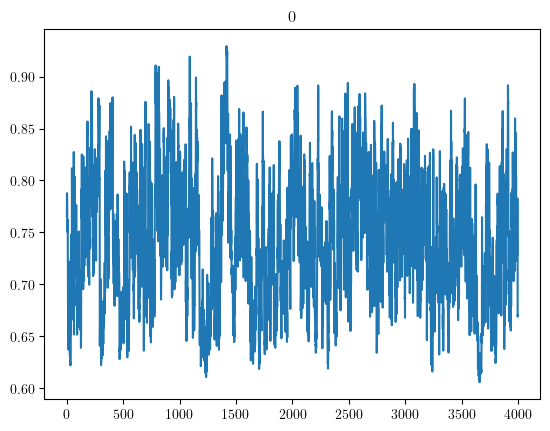

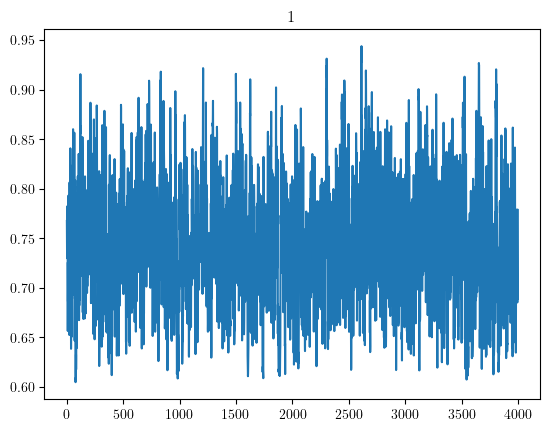

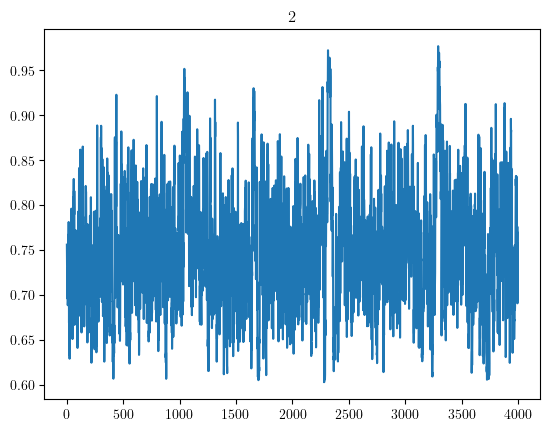

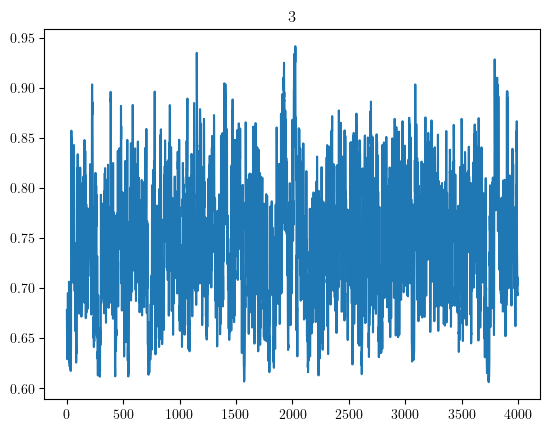

In [22]:
# df['potential_energy'].shape
# pl.plot(df['theta_ej_0'])
# pl.plot(df['sigma8'])
sig8 = df['sigma8']
# sig8 = df['alpha_1h2h_ym']
# sig8 = df['mu_beta']
# sig8 = df['A_IA']
# sig8 = df['theta_ej_0']
nchains = 4
sig8_rs = sig8.reshape(nchains,-1)
# for ji in range(12):
    # print(np.std(sig8_rs[ji]))
for ji in range(nchains):
    pl.figure()
    pl.plot(sig8_rs[ji])
    pl.title(ji)
    print(np.mean(sig8_rs[ji]))
    # pl.ylim(0.7, 1.0)
pl.show()



In [33]:
# df

{'A_IA': array([-0.00185808,  0.03987521,  0.65637392, ...,  0.17277358,
        -0.36388021, -0.04405343]),
 'A_IA_base': array([-0.0022297 ,  0.04785025,  0.7876487 , ...,  0.2073283 ,
        -0.43665625, -0.05286412]),
 'Delta_z_bias_array': array([[ 0.01548301, -0.00596382, -0.02646154,  0.02262028],
        [ 0.01951102,  0.00507924, -0.00943645,  0.02694576],
        [ 0.00469718,  0.01483049,  0.00482747,  0.00172311],
        ...,
        [ 0.02288331,  0.03071004, -0.00062261,  0.01212285],
        [-0.01676517,  0.01441487,  0.00823305,  0.0251777 ],
        [ 0.00215325,  0.01104671, -0.00550735,  0.01994213]]),
 'Delta_z_bias_array_decentered': array([[ 0.86016702, -0.39758832, -2.40559496,  1.3306046 ],
        [ 1.08394582,  0.33861579, -0.85785949,  1.58504447],
        [ 0.2609546 ,  0.98869921,  0.43886059,  0.10135959],
        ...,
        [ 1.27129511,  2.04733601, -0.05660087,  0.71310883],
        [-0.93139854,  0.96099126,  0.74845868,  1.48104105],
        [ 0.

(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(11400, 20)
Removed no burn in
1.0017087719148077


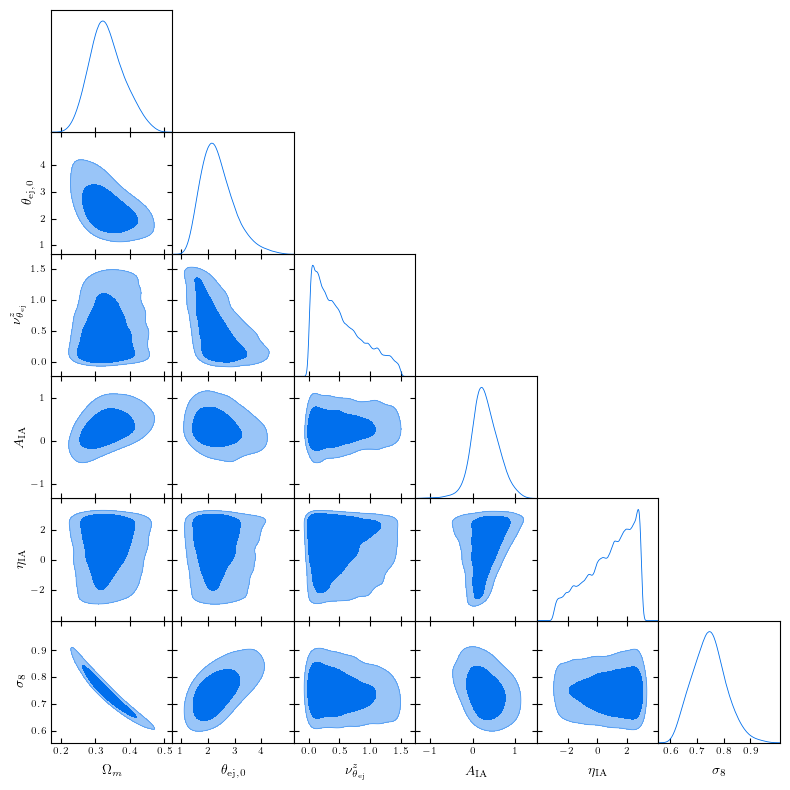

In [23]:
import dill
# df = dill.load(open(f'/project/def-lplevass/shivamp/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_3000_3000_num_chains_12_sample_thetaco_NUTS_update.pkl','rb'))
# df = dill.load(open(f'/project/def-lplevass/shivamp/GODMAX/results/chains/mcmc_probe_xip_xim_deproj_cib_1p7_dBeta_4000_8000_num_chains_12_sample_simple_NUTS_update.pkl','rb'))
# df = dill.load(open(f'/project/def-lplevass/shivamp/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_8000_num_chains_12_sample_simple_wide_thetaejM_NUTS_update.pkl','rb'))
# df = dill.load(open(f'/mnt/home/spandey/ceph/GODMAX/results/chains/mcmc_probe_gty_deproj_cib_1p7_dBeta_4000_7000_num_chains_12_sample_simple_zev_NUTS_update.pkl','rb'))
# df['s'].shape
# df
samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'diverging', 'potential_energy']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            # print(samps[0].shape)
            # print(df[key].shape)
            else:
                samps.append(df[key])
                keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
# ind_thetaejM = keys.index('nu_theta_ej_M')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'

labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'mu_beta':r'$\mu_{\beta}$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
 'nu_theta_co_z':r'$\nu^{z}_{\theta_{\rm co}}$', 
#  'nu_theta_ej_z',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$'
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
nchains = 4
samps_sel = samps.reshape(nchains,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# ind_del = np.array([4, 10])
# ind_del = np.array([3])
# ind_del = np.array([1,2,4,7])
# ind_del = np.array([0,7,8,9,10])
ind_del = [0]
# ind_del = [3,5,8]
# ind_del = [0,3,4,5,6,7,8,9,10,11]
if len(ind_del) > 0:
    samps_sel = np.delete(samps_sel, ind_del, axis=0)
# else:
    # samps_sel = samps_sel

samps = samps_sel.reshape(-1, samps_sel.shape[-1])
print(samps.shape)

saved = {'samps':samps, 'keys':keys, 'labels':labels, 'names':names}
savedir = '/projects/bdne/spandey3/GODMAX/results/ACTxDES/'
pk.dump(saved, open(savedir + 'samps_probes_all_npfNov_response_response.pkl', 'wb'))

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)

from numpyro.diagnostics import gelman_rubin
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(samps_sel.shape[0], -1))
print(gr)

# pl.figure()
# for ji in range(samps_sel.shape[0]):
    # print(ji, np.std(samps_sel[ji, :, ind_thetaejM]), np.mean(samps_sel[ji, :, ind_thetaejM]))
    # pl.plot(samps_sel[ji, :, ind_thetaejM], alpha=0.1)
# pl.savefig(save_plot_dir + 'temp.pdf')
# pl.show()
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M',  'nu_theta_ej_z', 'sigma8']
# params = ['Om0', 'gamma_rhogas', 'nu_theta_ej_M','nu_theta_ej_z','nu_theta_co_z', 'A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M','nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'alpha_ky', 'alpha_kk', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'gamma_rhogas', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8','alpha_1h2h_ym']
# params = ['Om0', 'theta_ej_0', 'mu_beta', 'nu_theta_ej_z','A_IA', 'eta_IA', 'alpha_nt', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'nu_theta_ej_M', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
params = ['Om0', 'theta_ej_0', 'nu_theta_ej_z','A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'theta_ej_0', 'A_IA', 'eta_IA', 'sigma8']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=8)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)

# g.export(save_plot_dir + 'xipm_simple_wide.pdf')
save_plot_dir = '/projects/bdne/spandey3/GODMAX/results/plots/ACTxDES/'
# g.export(save_plot_dir + 'test_fix_thetaej_mubeta.pdf')
# g.export(save_plot_dir + 'test_vary_thetaej_mubeta_all_npf_response_response.pdf')
# 
import matplotlib
%matplotlib inline
pl.show()




In [28]:
# samps.shape
# pl.figure()
# pl.show()
keys
# 

['A_IA',
 'Delta_z_bias_array_0',
 'Delta_z_bias_array_1',
 'Delta_z_bias_array_2',
 'Delta_z_bias_array_3',
 'Ob0',
 'Om0',
 'eta_IA',
 'h',
 'mult_shear_bias_array_0',
 'mult_shear_bias_array_1',
 'mult_shear_bias_array_2',
 'mult_shear_bias_array_3',
 'ns',
 'nu_theta_ej_z',
 'sigma8',
 'theta_ej_0',
 'S8']

In [12]:
import dill
# df = dill.load(open(f'/mnt/home/spandey/ceph/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_7000_num_chains_12_sample_simple_zev_NUTS_update.pkl','rb'))
# df = dill.load(open(f'/project/def-lplevass/shivamp/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_8000_num_chains_12_sample_simple_NUTS_update.pkl','rb'))

# samps = []
# keys = []
# for key in df:
#     if ('base' not in key) and ('decentered' not in key):
#         if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
#             for jb in range(4):
#                 samps.append(df[key][:, jb])
#                 keys.append(key + '_' + str(jb))
#                 print(df[key][:, jb].shape)
#         else:
#             samps.append(df[key])
#             keys.append(key)

samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if key not in ['prior_min', 'prior_max', 'fiducial_sims_params', 'diverging']:
            if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
                for jb in range(4):
                    samps.append(df[key][:, jb])
                    keys.append(key + '_' + str(jb))
                    print(df[key][:, jb].shape)
            else:
                samps.append(df[key])
                keys.append(key)            

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')


ind_post = keys.index('potential_energy')
post = -1.* samps[:,ind_post]

map_ind = np.where(post == post.max())[0][0]

saved_bestift = {}
for jk, key in enumerate(keys):
    print(key, samps[map_ind, jk])
    saved_bestift[key] = samps[map_ind, jk]

# pk.dump(saved_bestift, open('/projects/bdne/spandey3/GODMAX/results/ACTxDES/bestfits/bestift_params_fix_thetaej_mubeta_zev.pkl', 'wb'))
# pk.dump(saved_bestift, open('/projects/bdne/spandey3/GODMAX/results/ACTxDES/bestfits/bestift_params_vary_thetaej_mubeta_zev.pkl', 'wb'))
# pk.dump(saved_bestift, open('/projects/bdne/spandey3/GODMAX/results/ACTxDES/bestfits/bestift_params_vary_thetaej_mubeta_zev_response_response.pkl', 'wb'))
pk.dump(saved_bestift, open('/projects/bdne/spandey3/GODMAX/results/ACTxDES/bestfits/bestift_params_all_npf_response_response.pkl', 'wb'))



(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
(16000,)
A_IA 0.03485293314384963
Delta_z_bias_array_0 0.004669955967211396
Delta_z_bias_array_1 -0.00427273569116618
Delta_z_bias_array_2 -0.002328163895555022
Delta_z_bias_array_3 0.006853342574721976
Ob0 0.05207138376307267
Om0 0.3194041688204769
alpha_nt 0.30093015527198064
eta_IA -0.014408744274033491
h 0.5929903542035342
mu_beta 0.9413268436147318
mult_shear_bias_array_0 0.001031117926065959
mult_shear_bias_array_1 -0.014428278161614044
mult_shear_bias_array_2 -0.03255825711441124
mult_shear_bias_array_3 -0.037295125833280894
ns 1.0206878565584052
nu_theta_ej_z 1.1182669011317796
potential_energy -6560.75601786664
sigma8 0.777704457509983
theta_ej_0 3.063557713585345
S8 0.8024615843423186


In [7]:
# keys
%matplotlib inline


(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
Removed no burn in
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
Removed no burn in
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)
(48000,)


Removed no burn in


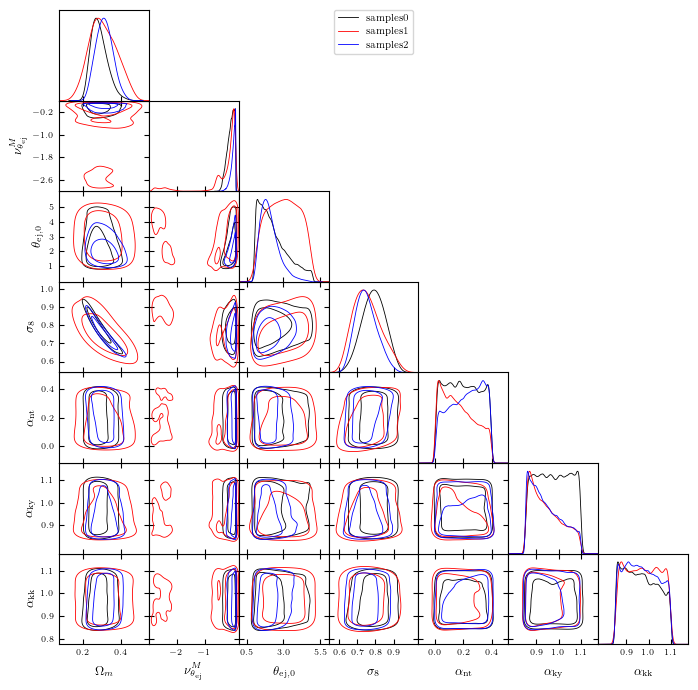

In [19]:
import dill
df = dill.load(open(f'/mnt/home/spandey/ceph/GODMAX/results/chains/mcmc_probe_all_deproj_cib_1p7_dBeta_4000_7000_num_chains_12_sample_simple_zev_NUTS_update.pkl','rb'))

samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
            for jb in range(4):
                samps.append(df[key][:, jb])
                keys.append(key + '_' + str(jb))
                print(df[key][:, jb].shape)
        else:
            samps.append(df[key])
            keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/project/def-lplevass/shivamp/GODMAX/results/chains/ACTxDES/'

labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
#  'nu_theta_ej_z',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$',
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
samps_sel = samps.reshape(12,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# ind_del = np.array([4, 10])
ind_del = np.array([2, 8])
samps_sel = np.delete(samps_sel, ind_del, axis=0)
samps = samps_sel.reshape(-1, samps_sel.shape[-1])
samples_all = MCSamples(samples=samps,names = names, labels = labels)

import dill
df = dill.load(open(f'/mnt/home/spandey/ceph/GODMAX/results/chains/mcmc_probe_gty_deproj_cib_1p7_dBeta_4000_7000_num_chains_12_sample_simple_zev_NUTS_update.pkl','rb'))

samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
            for jb in range(4):
                samps.append(df[key][:, jb])
                keys.append(key + '_' + str(jb))
                print(df[key][:, jb].shape)
        else:
            samps.append(df[key])
            keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/project/def-lplevass/shivamp/GODMAX/results/chains/ACTxDES/'

labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
#  'nu_theta_ej_z',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$', 
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
samps_sel = samps.reshape(12,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# ind_del = np.array([4, 10])
# ind_del = np.array([3, 8])
samps_sel = np.delete(samps_sel, ind_del, axis=0)
samps = samps_sel.reshape(-1, samps_sel.shape[-1])
samples_gty = MCSamples(samples=samps,names = names, labels = labels)

import dill
df = dill.load(open(f'/mnt/home/spandey/ceph/GODMAX/results/chains/mcmc_probe_xip_xim_deproj_cib_1p7_dBeta_4000_7000_num_chains_12_sample_simple_zev_NUTS_update.pkl','rb'))

samps = []
keys = []
for key in df:
    if ('base' not in key) and ('decentered' not in key):
        if ('Delta_z_bias_array' in key) or ('mult_shear_bias_array' in key):
            for jb in range(4):
                samps.append(df[key][:, jb])
                keys.append(key + '_' + str(jb))
                print(df[key][:, jb].shape)
        else:
            samps.append(df[key])
            keys.append(key)

samps = np.array(samps).T
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

import getdist
from getdist import plots, MCSamples

names = keys

save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'

labels_all = {'A_IA':r'$A_{\rm IA}$',
 'Ob0':r'$\Omega_b$',
 'Om0':r'$\Omega_m$',
 'eta_IA':r'$\eta_{\rm IA}$',
 'log10_Mc0':r'$\log(M_c)$',
 'theta_co_0':r'$\theta_{\rm co, 0}$',
 'gamma_rhogas':r'$\gamma$',
 'nu_z':r'$\nu_z$',
 'h':r'$h$',
 'ns':r'$n_s$',
 'nu_theta_ej_M':r'$\nu^{M}_{\theta_{\rm ej}}$',
 'nu_theta_ej_z':r'$\nu^{z}_{\theta_{\rm ej}}$',
#  'nu_theta_ej_z',
 'sigma8':r'$\sigma_8$',
 'theta_ej_0':r'$\theta_{\rm ej, 0}$',
 'S8':r'$S_8$',
 'alpha_nt':r'$\alpha_{\rm nt}$',
 'alpha_ky':r'$\alpha_{\rm ky}$',
 'alpha_kk':r'$\alpha_{\rm kk}$',
}

labels = []

for key in keys:
    if key in labels_all.keys():
        labels.append(labels_all[key])
    else:
        labels.append(r'm')

ind_frac_rm = 0.05
samps_sel = samps.reshape(12,-1, samps.shape[-1])
nsamp_per_chain = samps_sel.shape[1]
nrm = int(ind_frac_rm * nsamp_per_chain)
samps_sel = samps_sel[:, nrm:, :]

# ind_del = np.array([4, 10])
# ind_del = np.array([3, 8])
samps_sel = np.delete(samps_sel, ind_del, axis=0)
samps = samps_sel.reshape(-1, samps_sel.shape[-1])
samples_xipm = MCSamples(samples=samps,names = names, labels = labels)



# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'S8']
# params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'nu_theta_ej_z', 'theta_co_0', 'sigma8']
params = ['Om0', 'nu_theta_ej_M',  'theta_ej_0', 'sigma8', 'alpha_nt', 'alpha_ky', 'alpha_kk']
# params = ['Om0', 'nu_theta_ej_M', 'theta_co_0', 'sigma8', 'gamma_rhogas', 'S8']

g = plots.get_subplot_plotter(width_inch=7)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples_xipm, samples_gty, samples_all], params, filled=False, )
# g.triangle_plot([samples], filled=True)

g.export(save_plot_dir + 'all_comp_simple_wide_zev.pdf')
# g.export(save_plot_dir + 'xipm_simple.pdf')
# 




In [5]:
samps = np.array(samps)
ind_sigma8 = keys.index('sigma8')
ind_Om = keys.index('Om0')
samp_S8 = samps[:,ind_sigma8] * (samps[:,ind_Om]/0.3)**0.5

samps = np.concatenate([samps, samp_S8[:,None]], axis=1)
keys.append('S8')

# samps = samps[60000:80000,:]
samples = MCSamples(samples=samps,names = names, labels = labels)



Removed no burn in


In [6]:
# samps.shape
from numpyro.diagnostics import gelman_rubin
ind_gr = ind_sigma8
gr = gelman_rubin(samps[:, ind_gr].reshape(24, -1))
print(gr)


/mnt/home/spandey/miniconda3/envs/ili-sbi/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1.4386713945808833


In [9]:
import matplotlib
%matplotlib inline



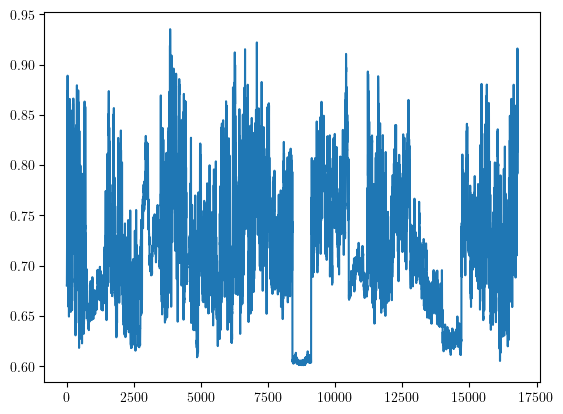

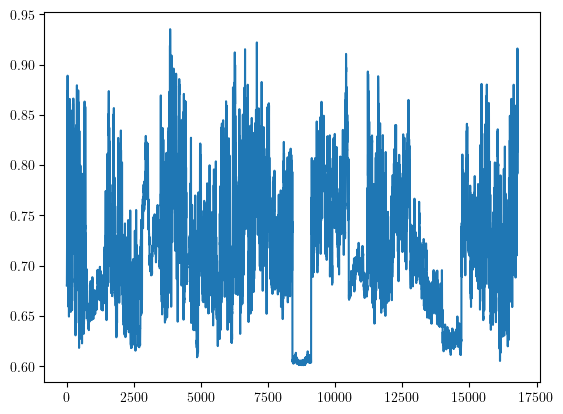

In [10]:
# samps.shape
pl.figure()
pl.plot(samps[:,ind_sigma8])


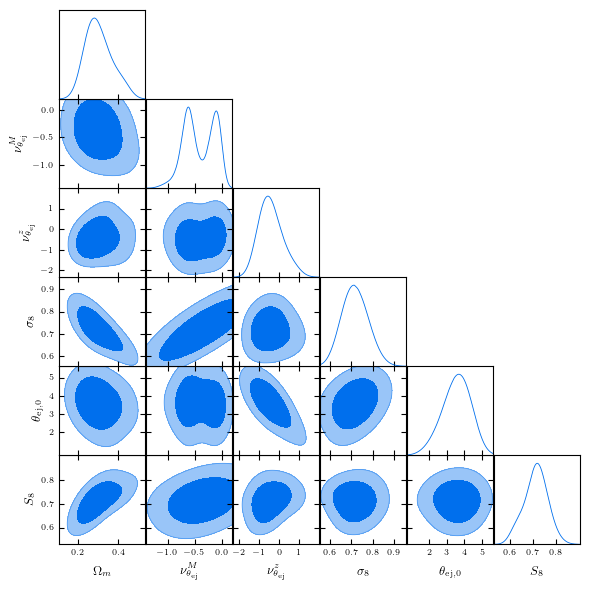

In [11]:
params = ['Om0', 'nu_theta_ej_M', 'nu_theta_ej_z', 'sigma8', 'theta_ej_0', 'S8']

g = plots.get_subplot_plotter(width_inch=6)
# g.triangle_plot([samples_xipxim, samples_gty, samples_all], params, filled=True)
g.triangle_plot([samples], params, filled=True)
# g.triangle_plot([samples], filled=True)
save_plot_dir = '/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/'
# g.export(save_plot_dir + f'triangle_plot_probe_{probe}_deproj_cib_1p7_dBeta_20000_1500_num_chains_5.png')



